<a href="https://colab.research.google.com/github/bodkhesakshi03-dotcom/Machine_Learning/blob/main/19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

df = pd.read_csv("train (2).csv")
print(df.head(10))


   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   
5   6          50       RL         85.0    14115   Pave   NaN      IR1   
6   7          20       RL         75.0    10084   Pave   NaN      Reg   
7   8          60       RL          NaN    10382   Pave   NaN      IR1   
8   9          50       RM         51.0     6120   Pave   NaN      Reg   
9  10         190       RL         50.0     7420   Pave   NaN      Reg   

  LandContour Utilities  ... PoolArea PoolQC  Fence MiscFeature MiscVal  \
0         Lvl    AllPub  ...        0    NaN    NaN         NaN       0   
1         Lvl    AllPub  ...       

In [3]:
missing = df.isnull().sum()
percent_missing = (missing / len(df)) * 100
print(pd.DataFrame({'Missing': missing, 'Percent': percent_missing}))

df.fillna(df.mean(numeric_only=True), inplace=True)
df.drop_duplicates(inplace=True)


               Missing    Percent
Id                   0   0.000000
MSSubClass           0   0.000000
MSZoning             0   0.000000
LotFrontage        259  17.739726
LotArea              0   0.000000
...                ...        ...
MoSold               0   0.000000
YrSold               0   0.000000
SaleType             0   0.000000
SaleCondition        0   0.000000
SalePrice            0   0.000000

[81 rows x 2 columns]


In [4]:
summary = df.describe()
print(summary)

target = df['SalePrice']
print("Min:", target.min())
print("Max:", target.max())
print("Mean:", target.mean())
print("Median:", target.median())


                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1460.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    22.024023    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    60.000000    7553.500000     5.000000   
50%     730.500000    50.000000    70.049958    9478.500000     6.000000   
75%    1095.250000    70.000000    79.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1460.000000  1460.000000   1460.000000  1460.000000  1460.000000  ...   
mean      5.575342  1971.267808   1984.865753   103.685262   443.639726  ...   
std       1.112799    30.202904     20.645407   180.569112   456.098091  ..

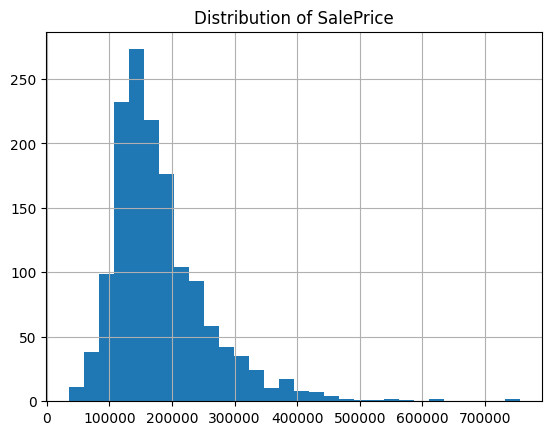

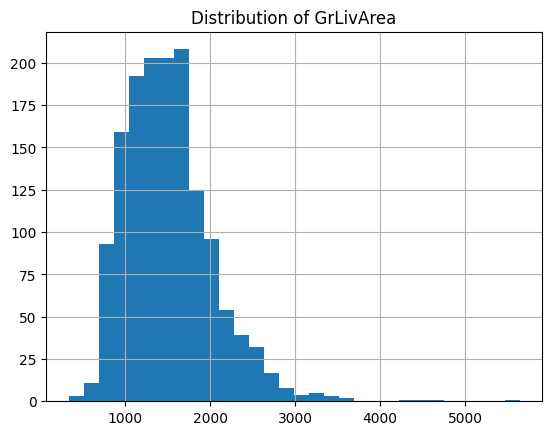

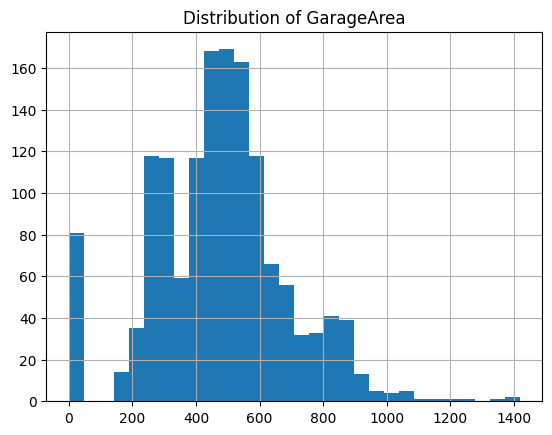

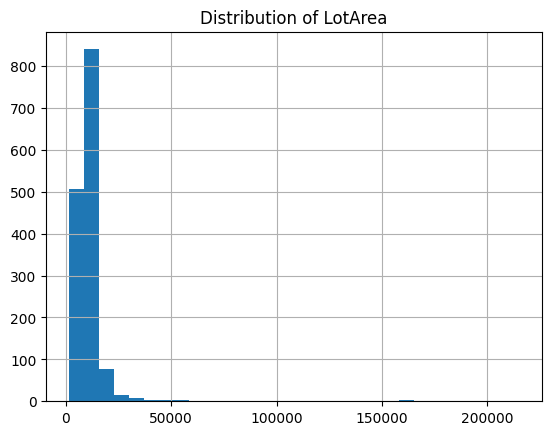

In [5]:
import matplotlib.pyplot as plt

numeric_cols = ['SalePrice','GrLivArea','GarageArea','LotArea']
for col in numeric_cols:
    df[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()


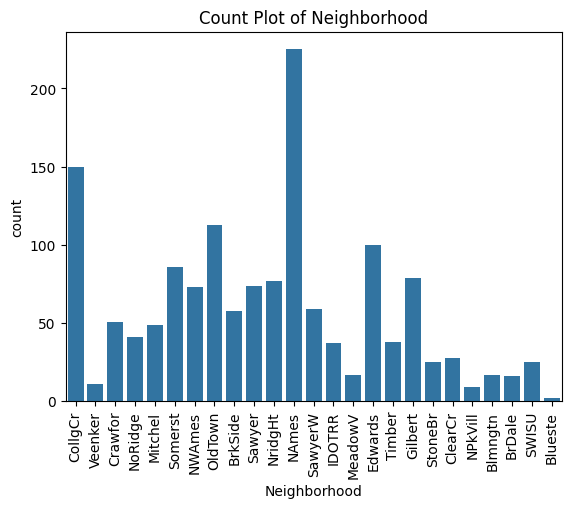

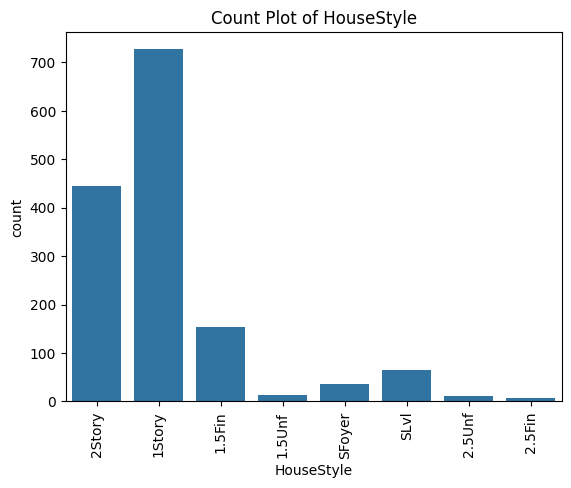

In [6]:
import seaborn as sns

categorical_cols = ['Neighborhood','HouseStyle']
for col in categorical_cols:
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=90)
    plt.title(f"Count Plot of {col}")
    plt.show()


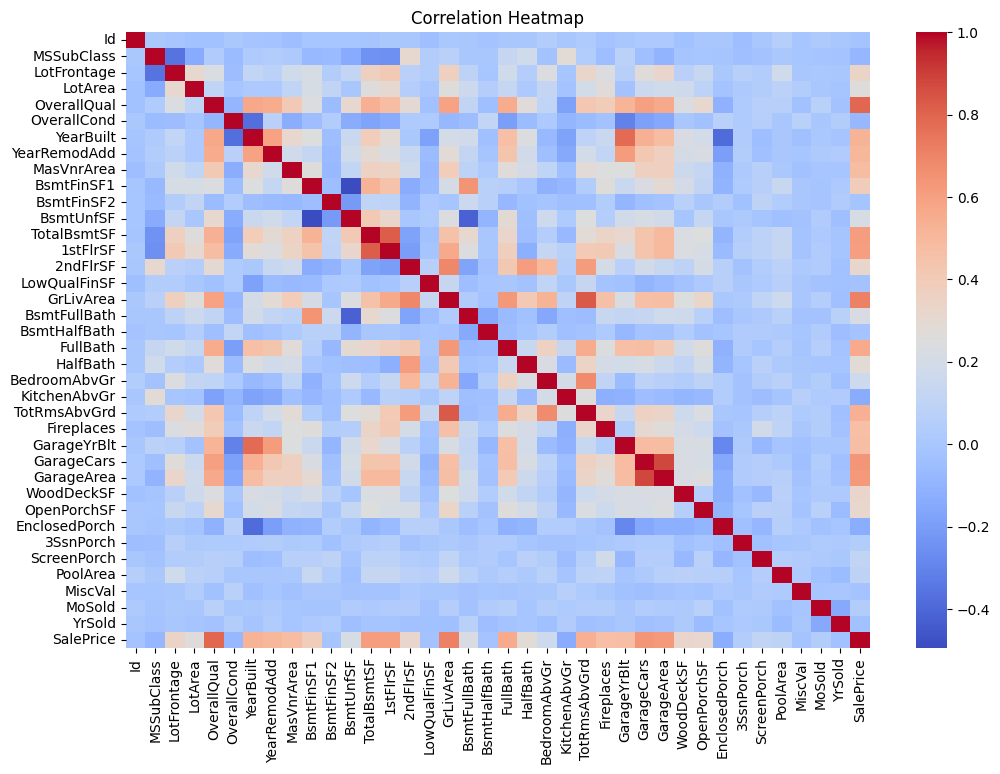

In [7]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [10]:
X = df.drop('SalePrice', axis=1)   # Independent features
y = df['SalePrice']                # Dependent feature

print("Independent Features (X):", list(X.columns)[:10], "...")
print("Dependent Feature (y): SalePrice")


Independent Features (X): ['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities'] ...
Dependent Feature (y): SalePrice


In [11]:
print("Before Encoding:")
print(df[['Neighborhood','HouseStyle']].head())

df_encoded = pd.get_dummies(df, columns=['Neighborhood','HouseStyle'])

print("After Encoding:")
print(df_encoded.head())


Before Encoding:
  Neighborhood HouseStyle
0      CollgCr     2Story
1      Veenker     1Story
2      CollgCr     2Story
3      Crawfor     2Story
4      NoRidge     2Story
After Encoding:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... Neighborhood_Timber Neighborhood_Veenker  \
0         Lvl    AllPub  ...               False                False   
1         Lvl    AllPub  ...               False                 True   
2         Lvl    AllPub  ...               False                False   
3         Lvl    AllPub  ...               False                False   
4

In [14]:
# Encode categorical variables first
df_encoded = pd.get_dummies(df, drop_first=True)

# Now scale only numeric features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_encoded.drop('SalePrice', axis=1))

scaled_df = pd.DataFrame(scaled_features, columns=df_encoded.drop('SalePrice', axis=1).columns)
print(scaled_df.head())


         Id  MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  \
0 -1.730865    0.073375    -0.229372 -0.207142     0.651479    -0.517200   
1 -1.728492   -0.872563     0.451936 -0.091886    -0.071836     2.179628   
2 -1.726120    0.073375    -0.093110  0.073480     0.651479    -0.517200   
3 -1.723747    0.309859    -0.456474 -0.096897     0.651479    -0.517200   
4 -1.721374    0.073375     0.633618  0.375148     1.374795    -0.517200   

   YearBuilt  YearRemodAdd  MasVnrArea  BsmtFinSF1  ...  SaleType_ConLI  \
0   1.050994      0.878668    0.511418    0.575425  ...       -0.058621   
1   0.156734     -0.429577   -0.574410    1.171992  ...       -0.058621   
2   0.984752      0.830215    0.323060    0.092907  ...       -0.058621   
3  -1.863632     -0.720298   -0.574410   -0.499274  ...       -0.058621   
4   0.951632      0.733308    1.364570    0.463568  ...       -0.058621   

   SaleType_ConLw  SaleType_New  SaleType_Oth  SaleType_WD  \
0       -0.058621     -0.30196